# Video Clip Extraction for 3D CNN 

The 3D CNN works on **raw pixels**, not MediaPipe landmarks.
For each gesture we:
1. Load its frames (from start_frame to end_frame)
2. Uniformly sample N=16 frames across the gesture
3. Resize each to 112x112
4. Stack into a clip of shape (16, 112, 112, 3)
5. Save as .npy so training doesn't re-read JPEGs every epoch

Output:
```
data/processed/train/   ← (16, 112, 112, 3) uint8 clips
data/processed/test/
```

In [13]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

from src.data.dataset import (
    load_train_test, find_frames_dirs, load_gesture_frames, GESTURE_NAMES
)

DATA_DIR = "../raw_data/raw"
CLIP_DIR = "../data/processed"

N_FRAMES = 16   # frames per clip
SIZE = 112      # spatial resolution (112x112)

train_df, test_df = load_train_test(DATA_DIR)
frame_dirs = find_frames_dirs(DATA_DIR)

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
Found 5 frame directories: ['frames', 'frames 2', 'frames 3', 'frames 4', 'frames 5']


## 1. Clip preparation function

In [14]:
def prepare_video_clip(video_name, start_frame, end_frame, frame_dirs,
                       n_frames=N_FRAMES, size=SIZE):
    """
    Load a gesture as a fixed-size video clip for 3D CNN.

    Uniformly samples n_frames across the gesture, resizes to size x size.

    Returns:
        np.array (n_frames, size, size, 3) uint8, or None if no frames.
    """
    # Load_gesture_frames already does uniform sampling via max_frames
    frames = load_gesture_frames(
        video_name, start_frame, end_frame, frame_dirs, max_frames=n_frames
    )
    if frames is None or len(frames) == 0:
        return None

    # Resize each frame to size x size
    resized = np.array([cv2.resize(f, (size, size)) for f in frames])

    # If a gesture had fewer than n_frames, pad by repeating the last frame
    if len(resized) < n_frames:
        pad = np.repeat(resized[-1:], n_frames - len(resized), axis=0)
        resized = np.concatenate([resized, pad], axis=0)

    return resized[:n_frames].astype(np.uint8)

## 2. Test on one gesture + visualize the 16 sampled frames

Gesture: Zoom-out  (38 original frames)
Clip shape: (16, 112, 112, 3)


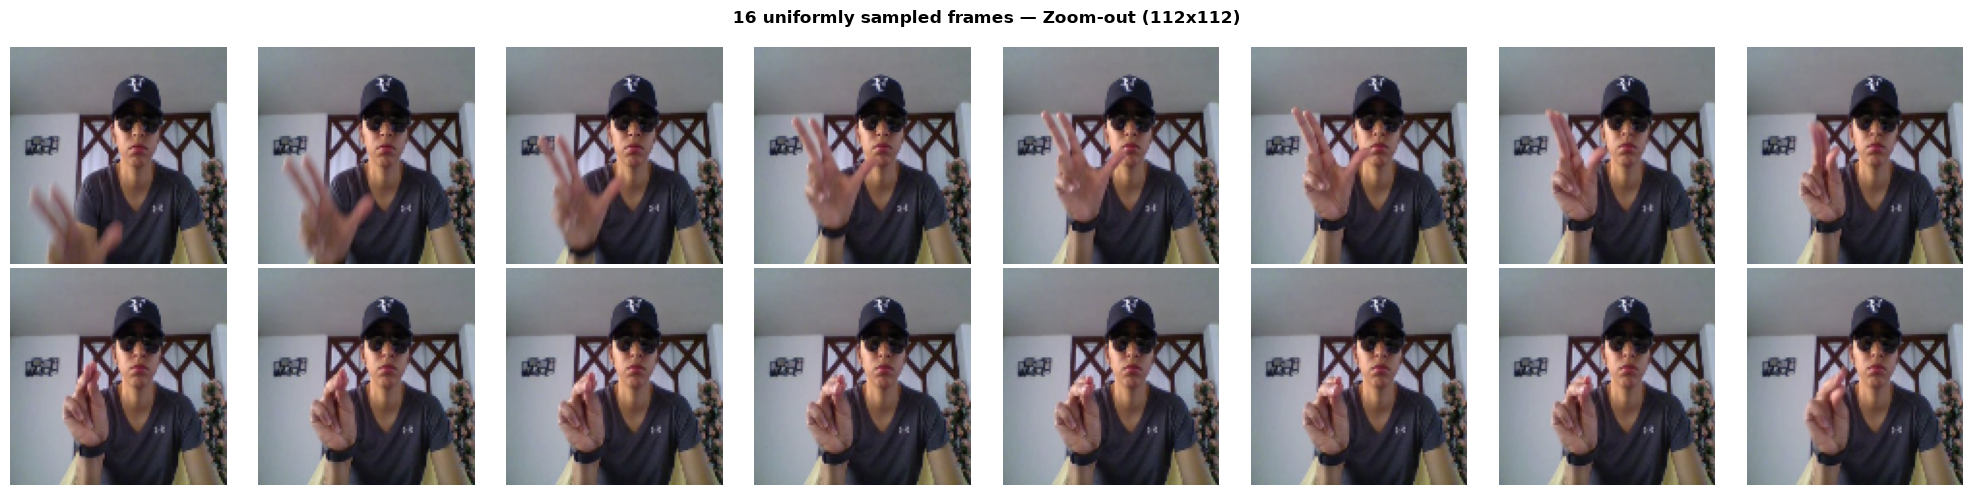

In [15]:
row = train_df.iloc[0]
clip = prepare_video_clip(row['video'], row['start_frame'], row['end_frame'],
                          frame_dirs)
print(f"Gesture: {row['gesture_name']}  ({row['n_frames']} original frames)")
print(f"Clip shape: {clip.shape if clip is not None else 'None'}")

if clip is not None:
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    for ax, frm in zip(axes.flatten(), clip):
        ax.imshow(frm)
        ax.axis('off')
    plt.suptitle(f"16 uniformly sampled frames — {row['gesture_name']} ({SIZE}x{SIZE})",
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. Compare a static vs a dynamic gesture

Static (Point) should look almost identical across frames;
dynamic (Zoom, Throw) should show clear motion.

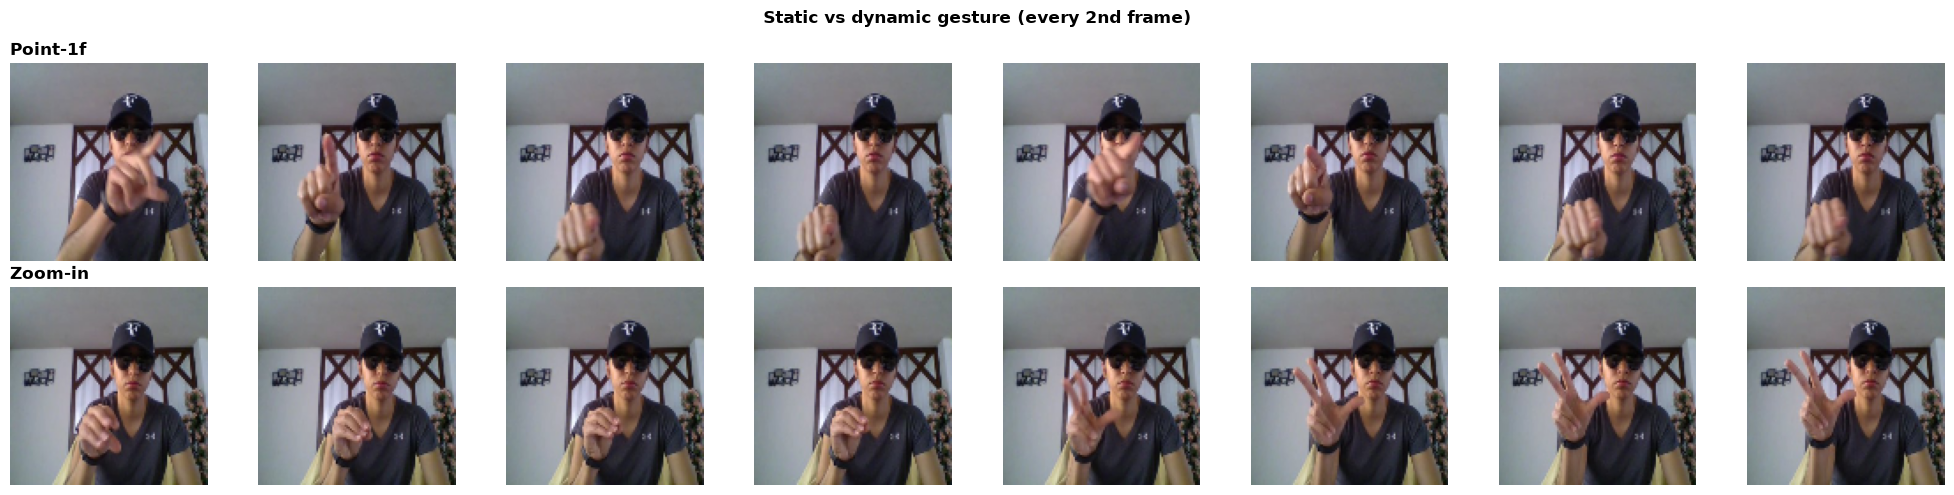

In [16]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for r_i, gesture in enumerate(['Point-1f', 'Zoom-in']):
    sample = train_df[train_df['gesture_name'] == gesture].iloc[0]
    clip = prepare_video_clip(sample['video'], sample['start_frame'],
                              sample['end_frame'], frame_dirs)
    if clip is not None:
        for c_i in range(8):
            axes[r_i, c_i].imshow(clip[c_i * 2])  # every 2nd frame
            axes[r_i, c_i].axis('off')
        axes[r_i, 0].set_ylabel(gesture, fontsize=12, fontweight='bold')
        axes[r_i, 0].set_title(gesture, loc='left', fontweight='bold')

plt.suptitle("Static vs dynamic gesture (every 2nd frame)", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Full extraction

Set `SUBSET = 200` to test the pipeline first, then `None` for the whole dataset.

In [17]:
def extract_dataset_clips(df, frame_dirs, output_dir, n_frames=N_FRAMES, size=SIZE):
    """Extract and save video clips for a whole split."""
    os.makedirs(output_dir, exist_ok=True)
    records = []
    skipped = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting clips"):
        clip = prepare_video_clip(
            row['video'], row['start_frame'], row['end_frame'],
            frame_dirs, n_frames=n_frames, size=size
        )
        if clip is None:
            skipped += 1
            continue

        npy_path = os.path.join(output_dir, f"{idx:05d}_class{row['label']}.npy")
        np.save(npy_path, clip)
        records.append({
            'index': idx,
            'label': row['label'],
            'gesture_name': row['gesture_name'],
            'npy_path': npy_path,
        })

    meta = pd.DataFrame(records)
    meta.to_csv(os.path.join(output_dir, "_metadata.csv"), index=False)
    print(f"\nDone. Extracted {len(records)} clips, skipped {skipped}.")
    print(f"Metadata saved to: {os.path.join(output_dir, '_metadata.csv')}")
    return meta

In [18]:
SUBSET = None   # set to None for the full run

train_subset = train_df.head(SUBSET) if SUBSET else train_df
test_subset = test_df.head(SUBSET // 4) if SUBSET else test_df

In [19]:
train_clips_meta = extract_dataset_clips(
    train_subset, frame_dirs, output_dir=f"{CLIP_DIR}/train"
)

Extracting clips: 100%|██████████| 3117/3117 [00:31<00:00, 99.87it/s] 


Done. Extracted 3117 clips, skipped 0.
Metadata saved to: ../data/processed/train/_metadata.csv


In [20]:
test_clips_meta = extract_dataset_clips(
    test_subset, frame_dirs, output_dir=f"{CLIP_DIR}/test"
)

Extracting clips: 100%|██████████| 1101/1101 [00:10<00:00, 100.89it/s]


Done. Extracted 1101 clips, skipped 0.
Metadata saved to: ../data/processed/test/_metadata.csv


## 5. Sanity check — reload a saved clip

In [21]:
sample_path = train_clips_meta.iloc[0]['npy_path']
loaded = np.load(sample_path)
print(f"Reloaded clip: {sample_path}")
print(f"  shape: {loaded.shape}")   # expect (16, 112, 112, 3)
print(f"  dtype: {loaded.dtype}")   # expect uint8
print(f"  value range: [{loaded.min()}, {loaded.max()}]")

Reloaded clip: ../data/processed/train/00000_class12.npy
  shape: (16, 112, 112, 3)
  dtype: uint8
  value range: [0, 255]


## Summary

Now we have video clips ready for the 3D CNN:
```
data/processed/train/   ← (16, 112, 112, 3) uint8 clips + _metadata.csv
data/processed/test/

In [22]:
print("Clip extraction complete.")
print(f"  Train clips: {CLIP_DIR}/train")
print(f"  Test clips:  {CLIP_DIR}/test")

Clip extraction complete.
  Train clips: ../data/processed/train
  Test clips:  ../data/processed/test
